## Load and Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
health_data = pd.read_csv("cbc_demo_merged_1999_2018.csv")

health_data.shape
health_data.head()
health_data.info()
health_data.describe()


<class 'pandas.DataFrame'>
RangeIndex: 92988 entries, 0 to 92987
Columns: 220 entries, SEQN to DMDHSEDZ
dtypes: float64(207), int64(9), str(4)
memory usage: 156.1 MB


,SEQN,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXEOPCT,LBXBAPCT,LBDLYMNO,LBDMONO,LBDNENO,...,DMDBORN4,AIALANGA,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRBR4,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ
count,92988.000000,82923.000000,82744.000000,82744.000000,82744.000000,82744.000000,82744.000000,82741.000000,82741.000000,82741.000000,...,35909.000000,23010.000000,35909.000000,35909.000000,35909.000000,26636.000000,8366.000000,7973.000000,8200.000000,4357.000000
mean,51172.066578,7.307269,33.616705,8.039510,54.659993,3.035912,0.701780,2.408662,0.570412,4.063330,...,1.250884,1.119991,0.484837,0.992648,0.433178,1.421535,2.888597,2.051298,1.473415,2.101905
std,29744.085046,2.743337,10.715035,2.360588,11.737409,2.438622,0.535253,1.773500,0.208942,1.788205,...,1.745351,0.369281,0.780974,1.169852,0.723554,2.919063,0.805552,0.655558,0.720495,0.687811
min,1.000000,1.400000,2.600000,0.600000,0.800000,0.000000,0.000000,0.200000,0.000000,0.100000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,25334.750000,5.700000,26.300000,6.500000,47.600000,1.500000,0.400000,1.800000,0.400000,2.800000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,2.000000,1.000000,2.000000
50%,50814.500000,7.000000,32.400000,7.800000,55.700000,2.400000,0.600000,2.200000,0.500000,3.800000,...,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,3.000000,2.000000,1.000000,2.000000
75%,77569.250000,8.500000,39.800000,9.300000,62.800000,3.800000,0.900000,2.800000,0.700000,5.000000,...,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,4.000000,2.000000,2.000000,3.000000
max,102956.000000,400.000000,94.500000,66.900000,96.600000,57.200000,35.400000,358.800000,10.200000,83.100000,...,99.000000,3.000000,3.000000,4.000000,3.000000,99.000000,4.000000,3.000000,3.000000,3.000000


## Select and Rename Variables

In [4]:
analysis_data = health_data[
    [
        "LBXHGB",      # Hemoglobin
        "RIDAGEYR",    # Age
        "RIAGENDR",    # Sex
        "RIDRETH1",    # Race
        "LBXRBCSI",    # Red blood cells
        "LBXHCT",      # Hematocrit
        "LBXMCVSI",    # MCV
        "LBXMCHSI",    # MCH
        "LBXRDW",      # RDW
        "LBXPLTSI",    # Platelets
        "LBXWBCSI"     # WBC
    ]
].copy()

analysis_data = analysis_data.rename(columns={
    "LBXHGB": "hemoglobin",
    "RIDAGEYR": "age",
    "RIAGENDR": "sex",
    "RIDRETH1": "race",
    "LBXRBCSI": "rbc",
    "LBXHCT": "hematocrit",
    "LBXMCVSI": "mcv",
    "LBXMCHSI": "mch",
    "LBXRDW": "rdw",
    "LBXPLTSI": "platelets",
    "LBXWBCSI": "wbc"
})


## Data Cleaning

In [5]:
analysis_data.isnull().mean() * 100


hemoglobin    10.820751
age            0.000000
sex            0.000000
race           0.000000
rbc           10.820751
hematocrit    10.820751
mcv           10.820751
mch           10.820751
rdw           10.820751
platelets     10.822902
wbc           10.823977
dtype: float64

In [6]:
analysis_data_clean = analysis_data.dropna()
analysis_data_clean.isnull().sum()

hemoglobin    0
age           0
sex           0
race          0
rbc           0
hematocrit    0
mcv           0
mch           0
rdw           0
platelets     0
wbc           0
dtype: int64

In [7]:
analysis_data_clean.corr()["hemoglobin"].sort_values(ascending=False)

hemoglobin    1.000000
hematocrit    0.966461
rbc           0.687433
mch           0.448381
mcv           0.425096
age           0.189573
wbc          -0.005612
race         -0.102479
platelets    -0.240562
rdw          -0.339869
sex          -0.431753
Name: hemoglobin, dtype: float64

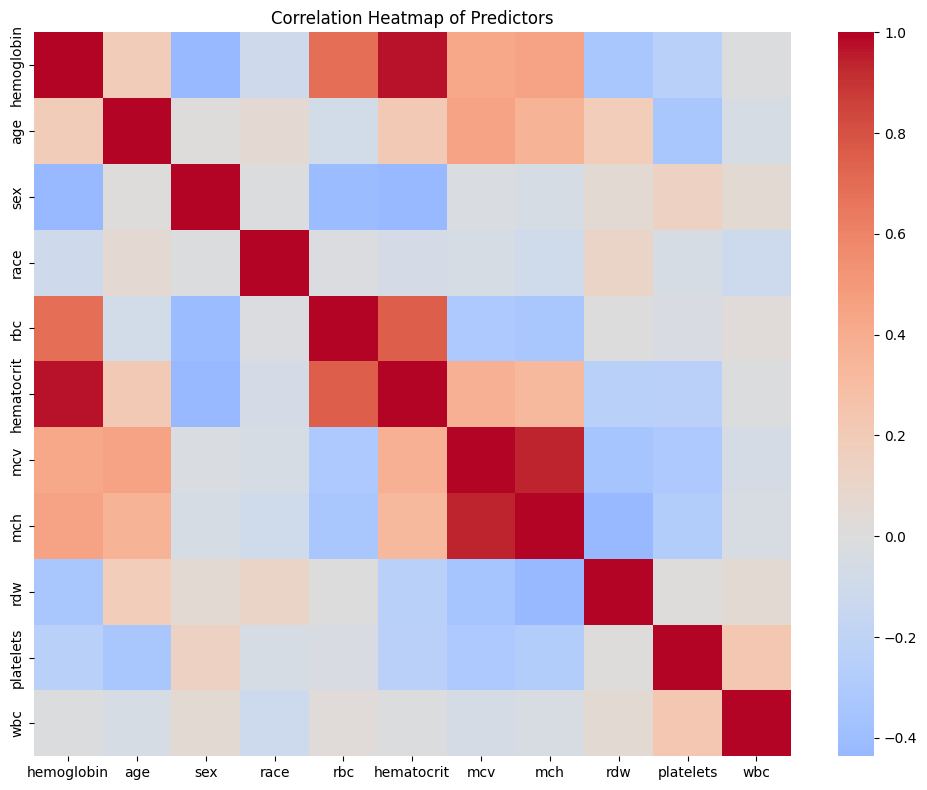

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    analysis_data_clean.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Predictors")
plt.tight_layout()
plt.show()

## Train / Test Split

In [9]:
X = analysis_data_clean.drop(columns=["hemoglobin"])
y = analysis_data_clean["hemoglobin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

##  LASSO for Variable Selection 

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
selected_vars = lasso_coefs[lasso_coefs != 0].index.tolist()

selected_vars


['age', 'sex', 'race', 'hematocrit', 'mcv', 'mch', 'rdw', 'wbc']

## Fit Full and Reduced Models

In [11]:
full_model = LinearRegression()
full_model.fit(X_train, y_train)

full_mse = mean_squared_error(
    y_test,
    full_model.predict(X_test)
)

## Reduced Model

In [12]:
reduced_model = LinearRegression()
reduced_model.fit(X_train[selected_vars], y_train)

reduced_mse = mean_squared_error(
    y_test,
    reduced_model.predict(X_test[selected_vars])
)


In [13]:
observed_difference = reduced_mse - full_mse
full_mse, reduced_mse, observed_difference

(0.004871962083722651, 0.005049326988894929, 0.00017736490517227844)

##  Permutation Test 

In [14]:
perm_diffs = []

for _ in range(1000):
    y_perm = np.random.permutation(y_train)

    full_model.fit(X_train, y_perm)
    reduced_model.fit(X_train[selected_vars], y_perm)

    mse_f = mean_squared_error(
        y_test,
        full_model.predict(X_test)
    )
    mse_r = mean_squared_error(
        y_test,
        reduced_model.predict(X_test[selected_vars])
    )

    perm_diffs.append(mse_r - mse_f)

perm_diffs = np.array(perm_diffs)
p_value = np.mean(perm_diffs >= observed_difference)
p_value

np.float64(0.133)

## Permutation Histogram

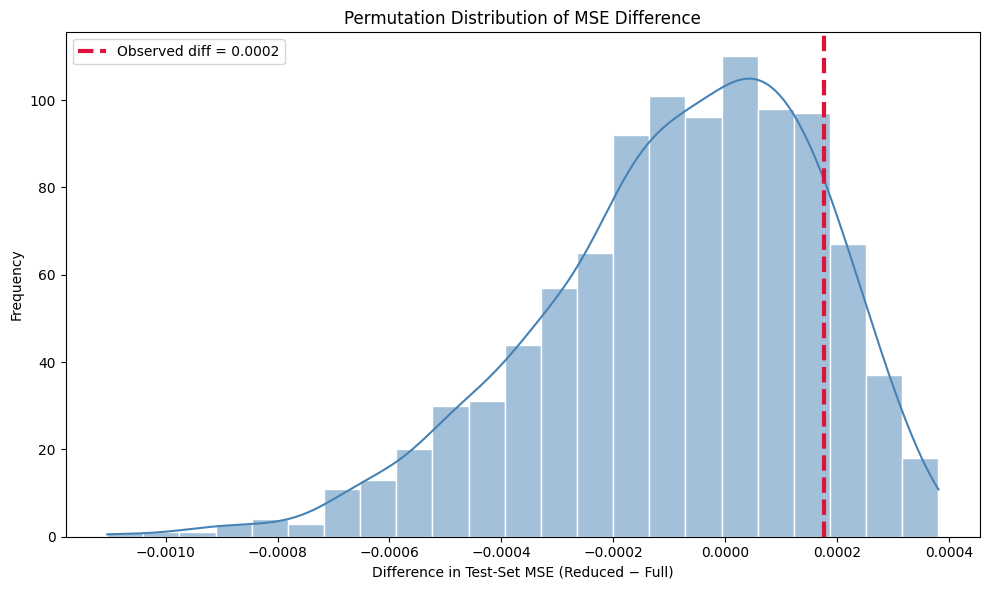

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(
    perm_diffs,
    kde=True,
    color="steelblue",
    edgecolor="white"
)

plt.axvline(
    observed_difference,
    color="crimson",
    linestyle="--",
    linewidth=3,
    label=f"Observed diff = {observed_difference:.4f}"
)

plt.xlabel("Difference in Test-Set MSE (Reduced − Full)")
plt.ylabel("Frequency")
plt.title("Permutation Distribution of MSE Difference")
plt.legend()
plt.tight_layout()
plt.show()


## Bootstrap (Stability of Full Model)

In [17]:
boot_mse = []

for _ in range(2000):
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    Xb = X_train.iloc[idx]
    yb = y_train.iloc[idx]

    full_model.fit(Xb, yb)
    preds = full_model.predict(X_test)

    boot_mse.append(mean_squared_error(y_test, preds))

boot_mse = np.array(boot_mse)
lower_ci, upper_ci = np.quantile(boot_mse, [0.025, 0.975])
lower_ci, upper_ci

(np.float64(0.0044481530208806295), np.float64(0.0063067599760833195))

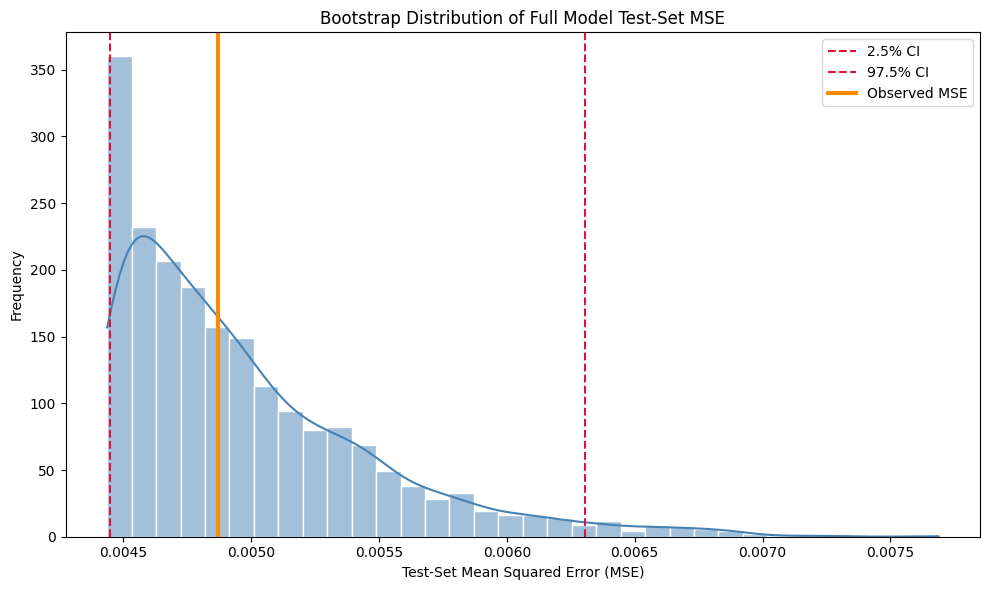

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(
    boot_mse,
    kde=True,
    color="steelblue",
    edgecolor="white"
)

plt.axvline(lower_ci, color="crimson", linestyle="--", label="2.5% CI")
plt.axvline(upper_ci, color="crimson", linestyle="--", label="97.5% CI")
plt.axvline(full_mse, color="darkorange", linewidth=3, label="Observed MSE")

plt.xlabel("Test-Set Mean Squared Error (MSE)")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Full Model Test-Set MSE")
plt.legend()
plt.tight_layout()
plt.show()
